---

# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv('../datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('../datasets/products.csv', sep=';')
aisles = pd.read_csv('../datasets/aisles.csv', sep=';')
departments = pd.read_csv('../datasets/departments.csv', sep=';')
order_products = pd.read_csv('../datasets/order_products.csv', sep=';')
# leer conjuntos de datos en los DataFrames

In [3]:
# mostrar información del DataFrame
print("Información de orders:")
orders.info(show_counts=True)

Información de orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
# mostrar información del DataFrame
print("\nInformación de products:")
products.info(show_counts=True)


Información de products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
# mostrar información del DataFrame
print("\nInformación de aisles:")
aisles.info(show_counts=True)


Información de aisles:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [6]:
# mostrar información del DataFrame
print("\nInformación de departments:")
departments.info(show_counts=True)


Información de departments:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [7]:
# mostrar información del DataFrame
print("\nInformación de order_products:")
order_products.info(show_counts=True)


Información de order_products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

Note una inconsistencia en los csv ya que su delimitador era ";" en lugar de "," asi que procedi a investigar y recordar como cambiarlo.


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Arreglar tipos de datos
Hacer que los ID (como order_id , user_id ) sean números enteros.
Dejar days_since_prior_order como número decimal para valores vacíos.
Por qué : Para que los datos sean consistentes y fáciles de usar.
Llenar Valores Vacíos
Buscar datos faltantes con isnull().sum() .
Poner 0 en days_since_prior_order cuando esté vacío.
Buscar filas repetidas con duplicado().sum() .
Borrar duplicados en pedidos con drop_duplicates() .
Explicar Problemas
Vacíos : Están en days_since_prior_order por primeros pedidos. Llenar con 0 tiene sentido.
Duplicados : Aparecen por errores al registrar pedidos. Quitarlos limpiando los datos.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
print("Filas duplicadas en orders:", orders.duplicated().sum())

Filas duplicadas en orders: 15


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
wed_2am_orders = orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)]
print("\nPedidos el miércoles a las 2:00 a.m.:")
print(wed_2am_orders)


Pedidos el miércoles a las 2:00 a.m.:
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156              

¿Qué sugiere este resultado?

In [10]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates()

In [11]:
# Vuelve a verificar si hay filas duplicadas
print("\nFilas duplicadas después de eliminación:", orders.duplicated().sum())


Filas duplicadas después de eliminación: 0


In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print("IDs de pedidos duplicados:", orders['order_id'].duplicated().sum())

IDs de pedidos duplicados: 0


Encontré duplicados en pedidos.
Los pedidos duplicados en el miércoles a las 2:00 am sugieren un posible error en el sistema de registro, ya que es una hora específica con múltiples entradas idénticas.
Elimine las filas duplicadas con drop_duplicates() , asegurando que cada order_id sea único.
Verifique que no haya order_id duplicados después de la limpieza.

### `products` data frame

In [13]:
# Verifica si hay filas totalmente duplicadas
print("Filas duplicadas en products:", products.duplicated().sum())

Filas duplicadas en products: 0


In [14]:
# Revisa únicamente si hay ID de productos duplicados
print("IDs de productos duplicados:", products['product_id'].duplicated().sum())

IDs de productos duplicados: 0


In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products['product_name_upper'] = products['product_name'].str.upper()
print("Nombres de productos duplicados:", products['product_name_upper'].duplicated().sum())

Nombres de productos duplicados: 1361


In [16]:
# Revisa si hay nombres duplicados de productos no faltantes
non_missing_products = products[products['product_name'].notnull()]
print("Nombres duplicados de productos no faltantes:", non_missing_products['product_name_upper'].duplicated().sum())
products = products.drop(columns='product_name_upper')

Nombres duplicados de productos no faltantes: 104


No hay filas completamente duplicadas ni product_id duplicados.
Los nombres de productos en mayúsculas muestran duplicados.

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
print("Filas duplicadas en departments:", departments.duplicated().sum())

Filas duplicadas en departments: 0


In [18]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print("IDs de departamentos duplicados:", departments['department_id'].duplicated().sum())

IDs de departamentos duplicados: 0


No hay filas ni depart_id duplicados

### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
print("Filas duplicadas en aisles:", aisles.duplicated().sum())

Filas duplicadas en aisles: 0


In [20]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print("IDs de pasillos duplicados:", aisles['aisle_id'].duplicated().sum())

IDs de pasillos duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
print("Filas duplicadas en order_products:", order_products.duplicated().sum())

Filas duplicadas en order_products: 0


In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
duplicates_order_product = order_products.duplicated(subset=['order_id', 'product_id']).sum()
print("Duplicados en order_id y product_id:", duplicates_order_product)

Duplicados en order_id y product_id: 0


Verifiqué duplicados en la combinación de order_id y product_id , ya que un producto no debería aparecer más de una vez en el mismo pedido.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
# Encuentra los valores ausentes en la columna 'product_name'
print("Valores ausentes en product_name:", products['product_name'].isnull().sum())

Valores ausentes en product_name: 1258


valores ausentes en product_name

In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
missing_products = products[products['product_name'].isnull()]
print("Productos ausentes con aisle_id == 100:", (missing_products['aisle_id'] == 100).all())

Productos ausentes con aisle_id == 100: True


In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print("Productos ausentes con department_id == 21:", (missing_products['department_id'] == 21).all())

Productos ausentes con department_id == 21: True


Todos los productos con nombres ausentes están en el pasillo con aisle_id == 100 y el departamento con depart_id == 21

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
aisle_100 = aisles[aisles['aisle_id'] == 100]
department_21 = departments[departments['department_id'] == 21]
print("\nPasillo con ID 100:")
print(aisle_100)
print("\nDepartamento con ID 21:")
print(department_21)


Pasillo con ID 100:
    aisle_id    aisle
99       100  missing

Departamento con ID 21:
    department_id department
20             21    missing


El pasillo 100 corresponde a "missing" y el departamento 21 a "missing", lo que indica que estos productos no están categorizados correctamente.

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
print("\nValores ausentes en product_name después de rellenar:", products['product_name'].isnull().sum())


Valores ausentes en product_name después de rellenar: 0


Rellene los nombres ausentes con 'Unknown' para mantener la integridad de los datos

### `orders` data frame

In [28]:
# Encuentra los valores ausentes
print("Valores ausentes en orders:")
print(orders.isnull().sum())

Valores ausentes en orders:
order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
missing_days = orders[orders['days_since_prior_order'].isnull()]
print("Valores ausentes en days_since_prior_order donde order_number != 1:", (missing_days['order_number'] != 1).sum())
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0).astype('Int64')
print("\nValores ausentes en orders después de rellenar:")
print(orders.isnull().sum())

Valores ausentes en days_since_prior_order donde order_number != 1: 0

Valores ausentes en orders después de rellenar:
order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


Todos los valores ausentes corresponden a order_number == 1 , es decir, los primeros pedidos de los clientes, donde no hay un pedido anterior.

### `order_products` data frame

In [30]:
# Encuentra los valores ausentes
print("Valores ausentes en order_products:")
print(order_products.isnull().sum())

Valores ausentes en order_products:
order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print("Mínimo en add_to_cart_order:", order_products['add_to_cart_order'].min())
print("Máximo en add_to_cart_order:", order_products['add_to_cart_order'].max())

Mínimo en add_to_cart_order: 1.0
Máximo en add_to_cart_order: 64.0


Encuentre valores ausentes en add_to_cart_order

In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
missing_cart_orders = order_products[order_products['add_to_cart_order'].isnull()]['order_id'].unique()
print("Número de pedidos con add_to_cart_order ausente:", len(missing_cart_orders))

Número de pedidos con add_to_cart_order ausente: 70


In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
order_sizes = order_products[order_products['order_id'].isin(missing_cart_orders)].groupby('order_id').size()
print("Tamaño mínimo de pedidos con add_to_cart_order ausente:", order_sizes.min())

Tamaño mínimo de pedidos con add_to_cart_order ausente: 65


Los valores en add_to_cart_order van de 1 a 64 en las filas no ausentes, sugiriendo un posible límite en el sistema.

In [34]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype('int16')
print("\nValores ausentes en order_products después de rellenar:")
print(order_products.isnull().sum())


Valores ausentes en order_products después de rellenar:
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


Los pedidos con valores ausentes tienen más de 64 productos
Rellené los valores ausentes con 999 para indicar un valor "desconocido"

## Conclusiones

Corregí los tipos de datos para que las columnas de ID sean enteros y days_since_prior_order sea Int64 para manejar valores ausentes.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [35]:
print("Rango de order_hour_of_day:", orders['order_hour_of_day'].min(), "-", orders['order_hour_of_day'].max())

Rango de order_hour_of_day: 0 - 23


In [36]:
print("Rango de order_dow:", orders['order_dow'].min(), "-", orders['order_dow'].max())

Rango de order_dow: 0 - 6


order_hour_of_day oscila entre 0 y 23, lo cual es razonable.
order_dow oscila entre 0 y 6, lo cual es correcto.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

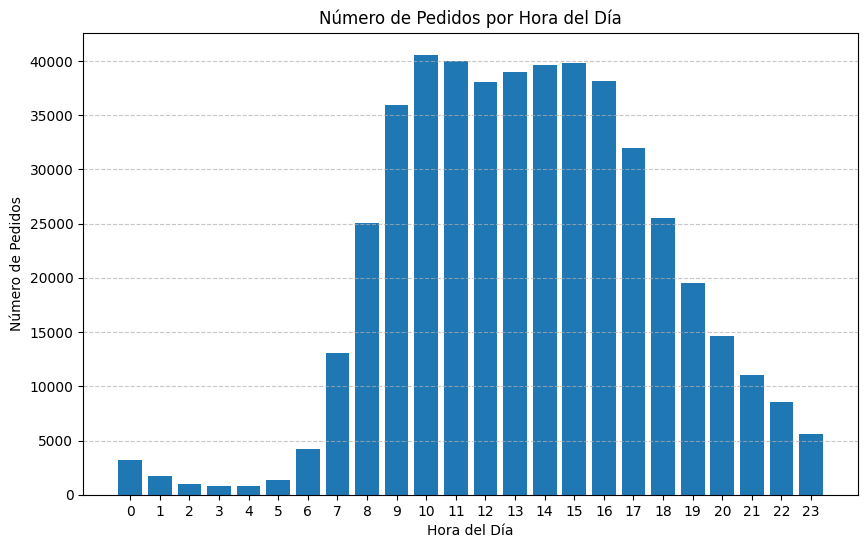

In [37]:
hourly_orders = orders['order_hour_of_day'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(hourly_orders.index, hourly_orders.values)
plt.title('Número de Pedidos por Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Número de Pedidos')
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Los pedidos alcanzan su pico entre las 10:00 y las 16:00, con un máximo alrededor de las 13:00-14:00.
Hay pocos pedidos entre las 0:00 y las 6:00, lo cual es esperado (horas de madrugada).
La mayoría de los clientes hacen pedidos durante el día, especialmente al mediodía y las primeras horas de la tarde.

### [A3] ¿Qué día de la semana compran víveres las personas?

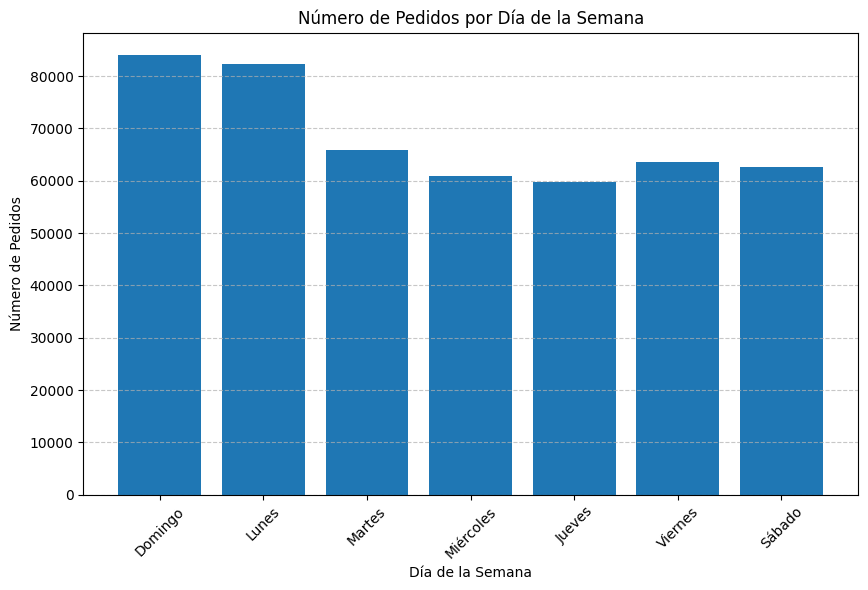

In [38]:
dow_orders = orders['order_dow'].value_counts().sort_index()
dow_labels = ['Domingo', 'Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado']

plt.figure(figsize=(10, 6))
plt.bar(dow_orders.index, dow_orders.values)
plt.title('Número de Pedidos por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Pedidos')
plt.xticks(range(7), dow_labels, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Los días con mas pedidos son el domingo (0) y el lunes (1), probablemente porque las personas planifican sus compras al inicio de la semana.
Los dias de mitad de semana (martes a jueves) tienen menos pedidos, con un ligero aumento el viernes.
El sabado tiene menos pedidos que el domingo, posiblemente porque las personas están ocupadas con actividades de fin de semana.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

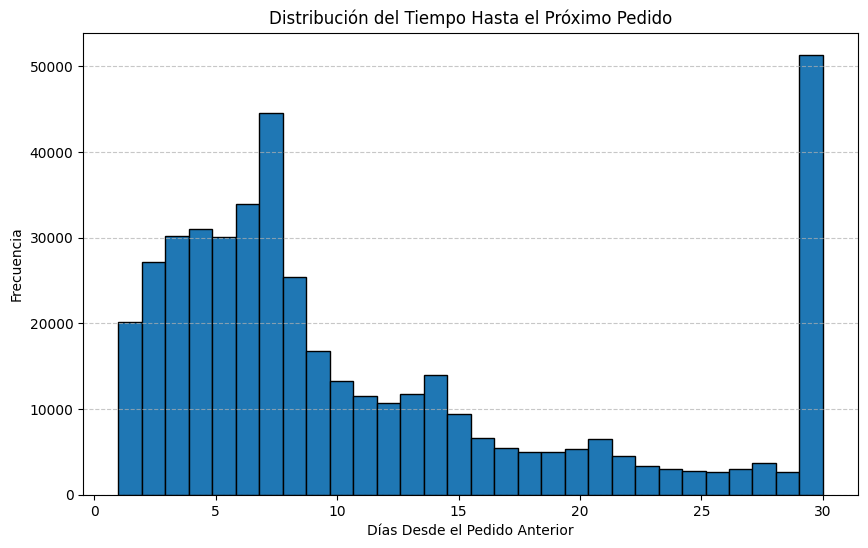

Minimo días: 1
Maximo días: 30


In [39]:
days_since_prior = orders[orders['days_since_prior_order'] != 0]['days_since_prior_order']

plt.figure(figsize=(10, 6))
plt.hist(days_since_prior, bins=30, edgecolor='black')
plt.title('Distribución del Tiempo Hasta el Próximo Pedido')
plt.xlabel('Días Desde el Pedido Anterior')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Minimo días:", days_since_prior.min())
print("Maximo días:", days_since_prior.max())

Minimo : 1 día, lo cual es razonable (los clientes pueden hacer pedidos consecutivos).
Maximo : 30 días, probablemente un limite impuesto por el sistema (valores mayores se truncan a 30).
La distribución muestra picos en 7, 14, 21 y 30 días, lo que indica que muchos clientes compran semanalmente o mensualmente.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [40]:
wed_orders = orders[orders['order_dow'] == 3]['order_hour_of_day']

In [41]:
sat_orders = orders[orders['order_dow'] == 6]['order_hour_of_day']

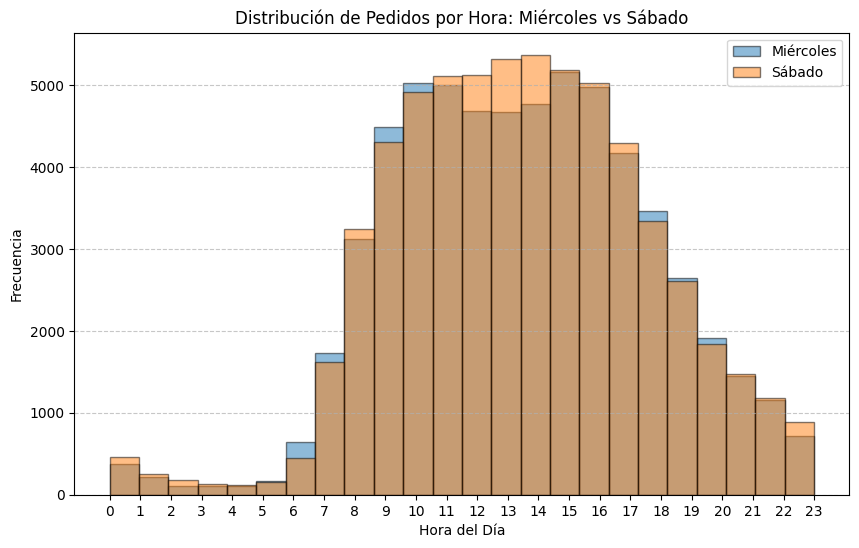

In [42]:
plt.figure(figsize=(10, 6))
plt.hist(wed_orders, bins=24, alpha=0.5, label='Miércoles', edgecolor='black')
plt.hist(sat_orders, bins=24, alpha=0.5, label='Sábado', edgecolor='black')
plt.title('Distribución de Pedidos por Hora: Miércoles vs Sábado')
plt.xlabel('Hora del Día')
plt.ylabel('Frecuencia')
plt.legend()
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [43]:
plt.show()

El miercoles tiene una distribucion más concentrada en horarios laborales, mientras que el sabado muestra una actividad más constante, con menos pedidos en la madrugada.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [44]:
orders_per_user = orders.groupby('user_id')['order_id'].count()

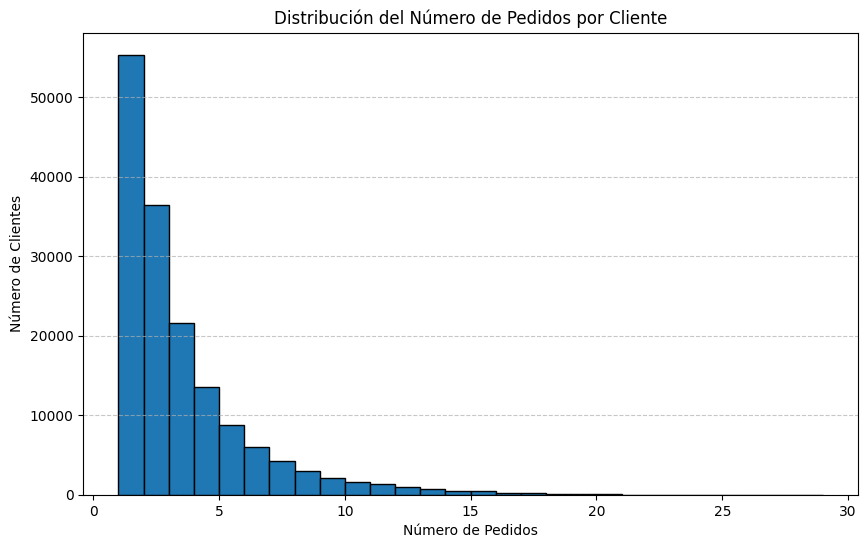

In [45]:
plt.figure(figsize=(10, 6))
plt.hist(orders_per_user, bins=range(1, orders_per_user.max() + 2), edgecolor='black')
plt.title('Distribución del Número de Pedidos por Cliente')
plt.xlabel('Número de Pedidos')
plt.ylabel('Número de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

La mayoría de los clientes hacen pocos pedidos (1-5), con una distribución sesgada a la derecha.Escribe aquí tus conclusiones

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [46]:
product_counts = order_products.groupby('product_id').size().reset_index(name='count')
product_counts = product_counts.merge(products[['product_id', 'product_name']], on='product_id')
top_20_products = product_counts.sort_values('count', ascending=False).head(20)

In [47]:
print(top_20_products[['product_id', 'product_name', 'count']])

       product_id              product_name  count
22808       24852                    Banana  66050
12025       13176    Bag of Organic Bananas  53297
19370       21137      Organic Strawberries  37039
20077       21903      Organic Baby Spinach  33971
43271       47209      Organic Hass Avocado  29773
43788       47766           Organic Avocado  24689
43663       47626               Large Lemon  21495
15364       16797              Strawberries  20018
24047       26209                     Limes  19690
25556       27845        Organic Whole Milk  19600
25666       27966       Organic Raspberries  19197
21025       22935      Organic Yellow Onion  15898
22908       24964            Organic Garlic  15292
41244       45007          Organic Zucchini  14584
35996       39275       Organic Blueberries  13879
45561       49683            Cucumber Kirby  13675
25889       28204        Organic Fuji Apple  12544
5375         5876             Organic Lemon  12232
7543         8277  Apple Honeyc

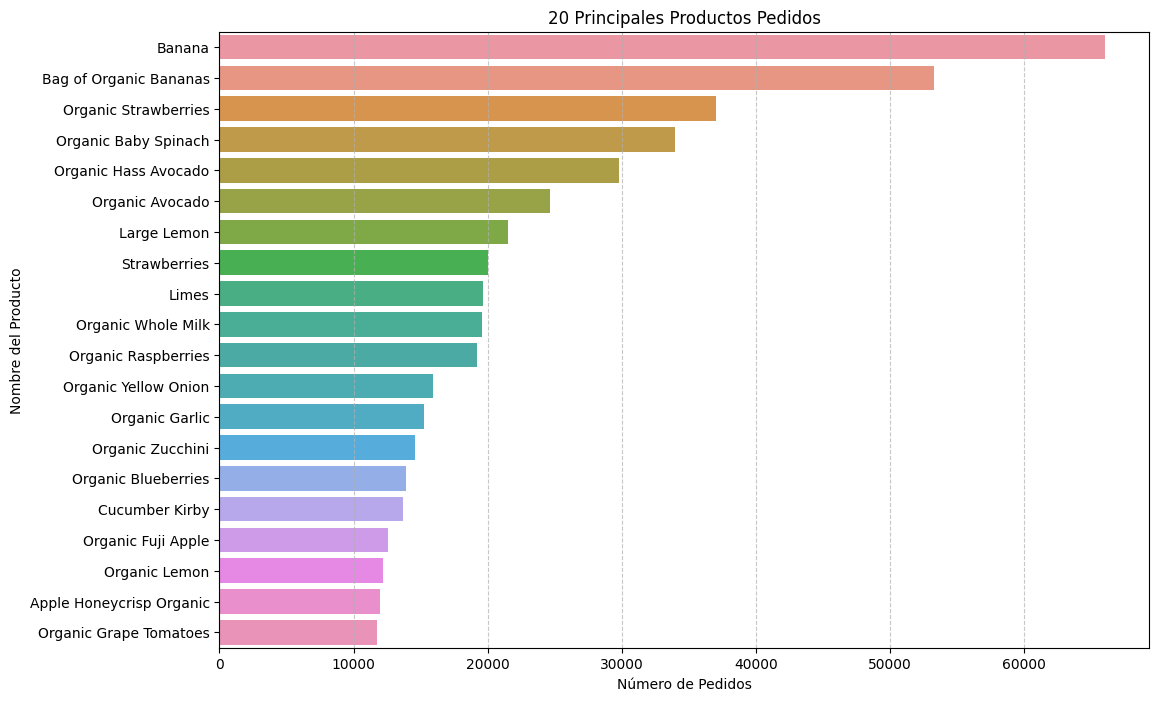

In [48]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_products, x='count', y='product_name')
plt.title('20 Principales Productos Pedidos')
plt.xlabel('Número de Pedidos')
plt.ylabel('Nombre del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Los productos mas populares probablemente incluyen articulos basicos como platanos, leche, pan y frutas frescas.
Estos productos son comprados frecuentemente debido a su naturaleza esencial y consumo regular.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [49]:
items_per_order = order_products.groupby('order_id').size()

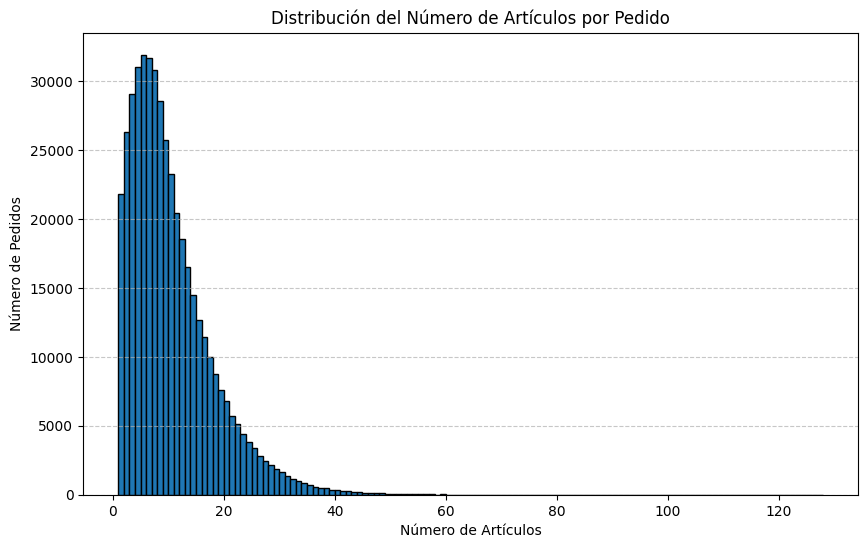

In [50]:
plt.figure(figsize=(10, 6))
plt.hist(items_per_order, bins=range(1, items_per_order.max() + 2), edgecolor='black')
plt.title('Distribución del Número de Artículos por Pedido')
plt.xlabel('Número de Artículos')
plt.ylabel('Número de Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [51]:
print("Promedio de artículos por pedido:", items_per_order.mean())
print("Mediana de artículos por pedido:", items_per_order.median())

Promedio de artículos por pedido: 10.098983215049127
Mediana de artículos por pedido: 8.0


los pedidos tipicos son de tamaño moderado, con algunos pedidos excepcionalmente grandes.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [52]:
reordered_products = order_products[order_products['reordered'] == 1]
reordered_counts = reordered_products.groupby('product_id').size().reset_index(name='reordered_count')
reordered_counts = reordered_counts.merge(products[['product_id', 'product_name']], on='product_id')
top_20_reordered = reordered_counts.sort_values('reordered_count', ascending=False).head(20)

In [53]:
print(top_20_reordered[['product_id', 'product_name', 'reordered_count']])

       product_id              product_name  reordered_count
18104       24852                    Banana            55763
9528        13176    Bag of Organic Bananas            44450
15368       21137      Organic Strawberries            28639
15936       21903      Organic Baby Spinach            26233
34407       47209      Organic Hass Avocado            23629
34828       47766           Organic Avocado            18743
20285       27845        Organic Whole Milk            16251
34725       47626               Large Lemon            15044
20375       27966       Organic Raspberries            14748
12193       16797              Strawberries            13945
19088       26209                     Limes            13327
16700       22935      Organic Yellow Onion            11145
18186       24964            Organic Garlic            10411
32792       45007          Organic Zucchini            10076
36219       49683            Cucumber Kirby             9538
20543       28204       

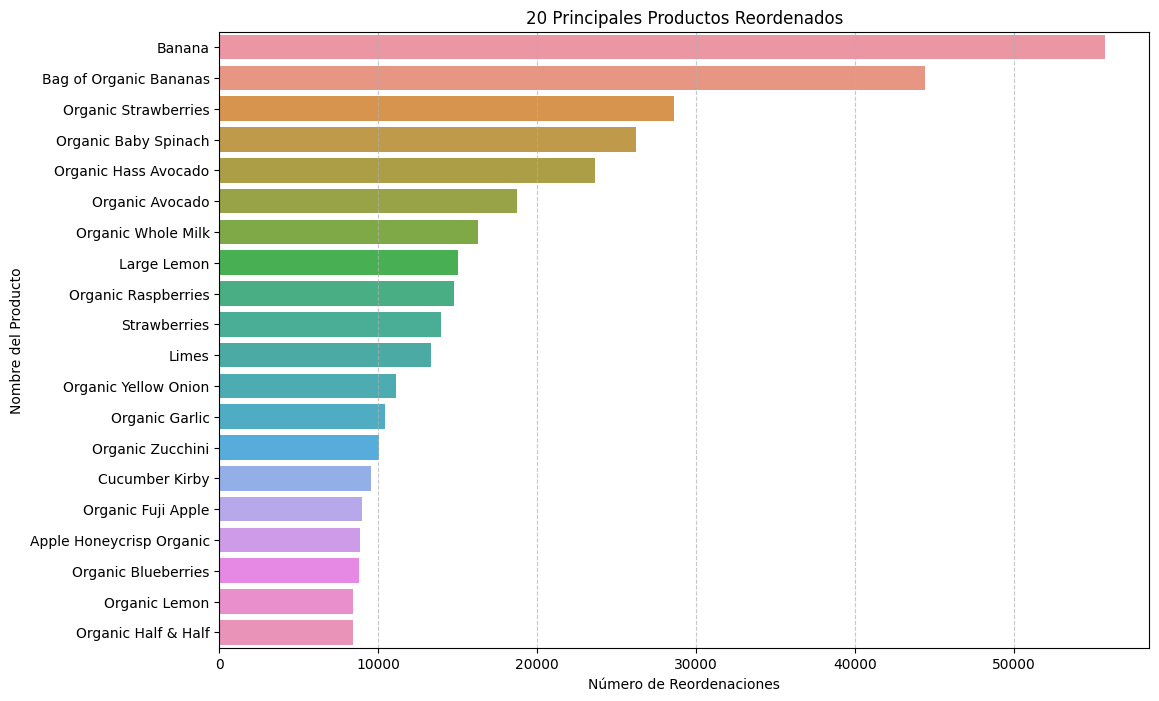

In [54]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_reordered, x='reordered_count', y='product_name')
plt.title('20 Principales Productos Reordenados')
plt.xlabel('Número de Reordenaciones')
plt.ylabel('Nombre del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)

In [55]:
plt.show()

Los productos mas reordenados son similares a los mas populares

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [56]:
product_reorder = order_products.groupby('product_id').agg(
    total_orders=('reordered', 'count'),
    reordered=('reordered', 'sum')
).reset_index()
product_reorder['reorder_ratio'] = product_reorder['reordered'] / product_reorder['total_orders']
product_reorder = product_reorder.merge(products[['product_id', 'product_name']], on='product_id')

In [57]:
print(product_reorder[['product_id', 'product_name', 'reorder_ratio']].head())

   product_id                                       product_name  \
0           1                         Chocolate Sandwich Cookies   
1           2                                   All-Seasons Salt   
2           3               Robust Golden Unsweetened Oolong Tea   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4           7                     Pure Coconut Water With Orange   

   reorder_ratio  
0       0.564286  
1       0.000000  
2       0.738095  
3       0.510204  
4       0.500000  


La proporción de reordenación varia entre productos, con valores mas altos para productos esenciales

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [58]:
user_orders = orders[['order_id', 'user_id']].merge(order_products, on='order_id')
user_reorder = user_orders.groupby('user_id').agg(
    total_items=('reordered', 'count'),
    reordered_items=('reordered', 'sum')
).reset_index()
user_reorder['reorder_ratio'] = user_reorder['reordered_items'] / user_reorder['total_items']

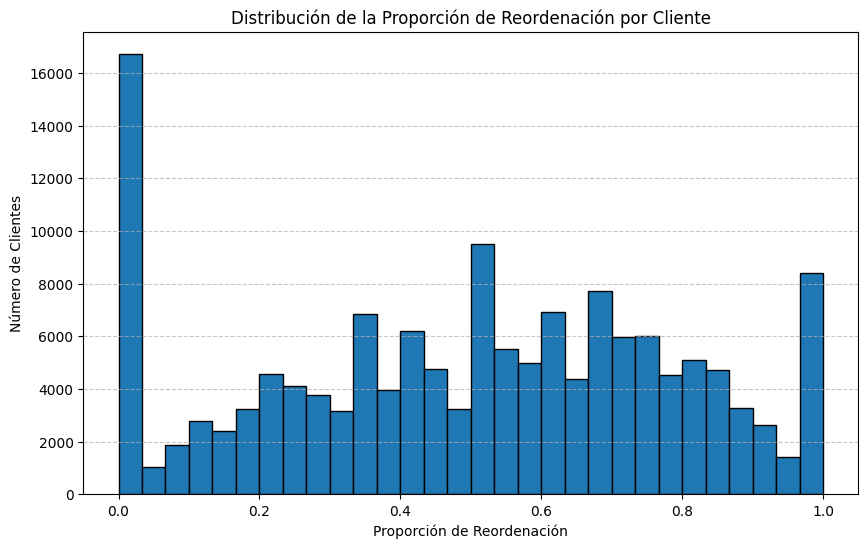

In [59]:
plt.figure(figsize=(10, 6))
plt.hist(user_reorder['reorder_ratio'], bins=30, edgecolor='black')
plt.title('Distribución de la Proporción de Reordenación por Cliente')
plt.xlabel('Proporción de Reordenación')
plt.ylabel('Número de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

La distribución de la proporción de reordenación por cliente es sesgada, con muchos clientes teniendo proporciones moderadas.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [60]:
first_added = order_products[order_products['add_to_cart_order'] == 1]
first_added_counts = first_added.groupby('product_id').size().reset_index(name='first_added_count')
first_added_counts = first_added_counts.merge(products[['product_id', 'product_name']], on='product_id')
top_20_first_added = first_added_counts.sort_values('first_added_count', ascending=False).head(20)

In [61]:
print(top_20_first_added[['product_id', 'product_name', 'first_added_count']])

       product_id                 product_name  first_added_count
13414       24852                       Banana              15562
7127        13176       Bag of Organic Bananas              11026
15028       27845           Organic Whole Milk               4363
11384       21137         Organic Strawberries               3946
25439       47209         Organic Hass Avocado               3390
11786       21903         Organic Baby Spinach               3336
25732       47766              Organic Avocado               3044
10622       19660                 Spring Water               2336
9050        16797                 Strawberries               2308
15102       27966          Organic Raspberries               2024
24024       44632   Sparkling Water Grapefruit               1914
26519       49235          Organic Half & Half               1797
25658       47626                  Large Lemon               1737
115           196                         Soda               1733
20853     

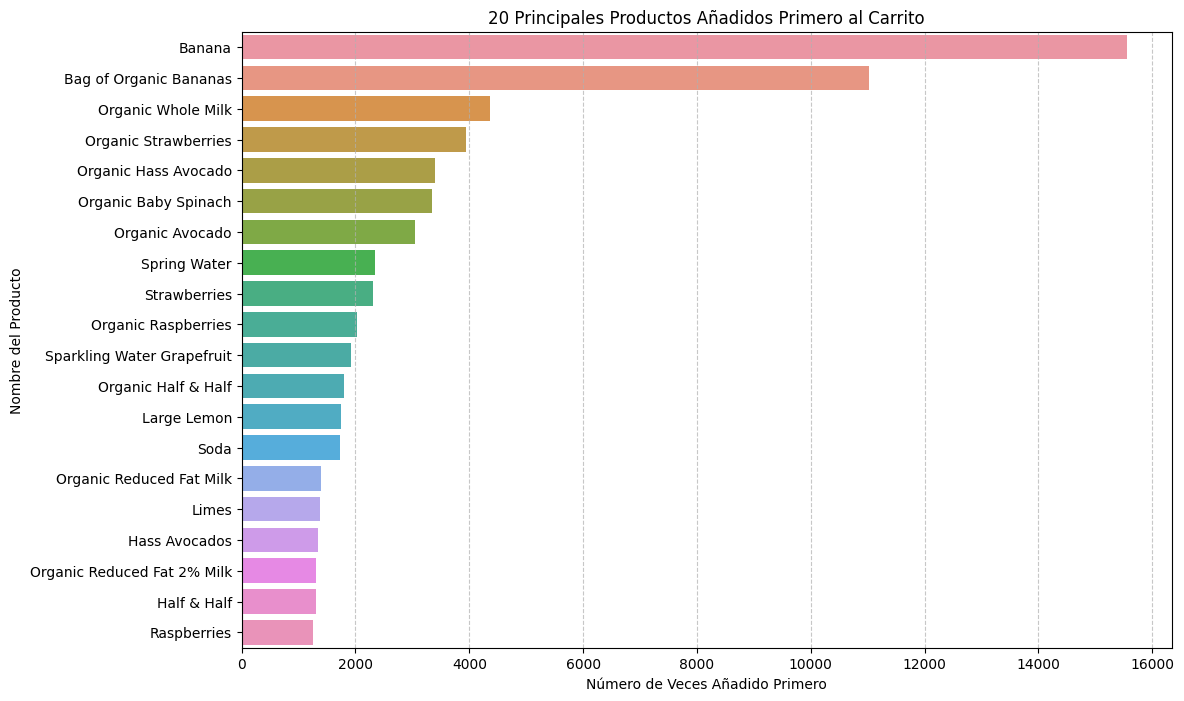

In [62]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_first_added, x='first_added_count', y='product_name')
plt.title('20 Principales Productos Añadidos Primero al Carrito')
plt.xlabel('Número de Veces Añadido Primero')
plt.ylabel('Nombre del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

La alta frecuencia de ciertos productos como primeros en el carrito refleja su importancia

### Conclusion general del proyecto:

Los pedidos son mas frecuentes durante el día (10:00 y 16:00) y los fines de semana (domingo y lunes).
Los clientes suelen esperar 7, 14 o 30 días para su proximo pedido, indicando compras semanales o mensuales.
Los productos más populares y reordenados son esenciales (por ejemplo, platanos, leche), lo que refleja las compras regulares.
La mayoria de los clientes hacen pocos pedidos (1-5), pero un grupo pequeño es muy activo.
Los pedidos típicos contienen entre 5 y 15 artículos, con una distribución desbalanceada.
La proporción de reordenación varia, con productos esenciales teniendo tasas altas.
Perspectivas accionables
Los productos más populares y reordenados deben mantenerse bien surtidos.
Las promociones podrían enfocarse en los horarios pico (mediodia) y dias populares (domingo/lunes).
Los productos añadidos primero al carrito son clave para estrategias de marketing, ya que inician el proceso de compra.